In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
os.getcwd()

'/Users/kevinlee-talka/Desktop/Research/lrp/src/experiments/lxt_experiments'

In [7]:
import os
import sys
module_path = os.path.join(os.getcwd(), '../../../external/LRP-eXplains-Transformers')
sys.path.append(module_path)

In [8]:
from lxt.efficient import monkey_patch

/Users/kevinlee-talka/Desktop/Research/lrp/src/experiments/lxt_experiments/../../../external/LRP-eXplains-Transformers/lxt/efficient/zennit_patches.py:22: UserWarning: 'zennit' library is not available. Please install it to use for vision transformers.
  warn("'zennit' library is not available. Please install it to use for vision transformers.")


In [3]:
import torch

In [4]:
from transformers import AutoTokenizer
from transformers.models.bert import modeling_bert

In [5]:
monkey_patch(modeling_bert)

In [6]:
model_name = "google-bert/bert-large-uncased-whole-word-masking-finetuned-squad"
model = modeling_bert.BertForQuestionAnswering.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Some weights of the model checkpoint at google-bert/bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [7]:
model

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,)

In [10]:
context = """Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50."""
question = "Which NFL team represented the AFC at Super Bowl 50?"
input_ids = tokenizer(question, context, return_tensors="pt")
input_embeds = model.bert.embeddings(input_ids["input_ids"])

In [11]:
input_embeds.retain_grad()

In [12]:
input_embeds.shape

torch.Size([1, 171, 1024])

In [13]:
output = model(inputs_embeds=input_embeds.requires_grad_())

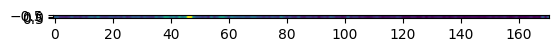

In [14]:
from matplotlib import pyplot as plt

plt.imshow((output.start_logits + output.end_logits).float().detach().numpy())

In [15]:
output.start_logits.argmax(), output.end_logits.argmax()
tokenizer.decode(input_ids["input_ids"][0, output.start_logits.argmax():output.end_logits.argmax() + 1])

'denver broncos'

In [16]:
logits = torch.stack((output.start_logits.max(), output.end_logits.max()))
logits.sum().backward()

In [17]:
relevance = (input_embeds * input_embeds.grad).sum(-1)

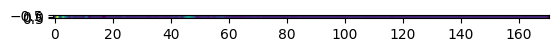

In [22]:
plt.imshow(relevance.detach().float().cpu().numpy())

In [23]:
relevance.topk(5)

torch.return_types.topk(
values=tensor([[11.2500,  8.0625,  6.1562,  4.6875,  3.9219]], dtype=torch.bfloat16,
       grad_fn=<TopkBackward0>),
indices=tensor([[ 1,  3, 46, 47, 45]]))

# Using DynamicLRP

In [1]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer
import torch

In [1]:
import os
import sys
module_path = os.path.join(os.getcwd(), '../..')
sys.path.append(module_path)

In [4]:
from lrp_engine import LRPEngine

In [4]:
model_name = "google-bert/bert-large-uncased-whole-word-masking-finetuned-squad"
model = AutoModelForQuestionAnswering.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Some weights of the model checkpoint at google-bert/bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [5]:
lrp = LRPEngine(dtype=torch.bfloat16)

In [6]:
context = """Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50."""
question = "Which NFL team represented the AFC at Super Bowl 50?"
input_ids = tokenizer(question, context, return_tensors="pt")["input_ids"]

In [7]:
output = model(input_ids)

In [8]:
lrp_output = lrp.run((output.start_logits, output.end_logits))

In [9]:
lrp_output

([],
 [tensor([[ 2.0752e-03,  1.9684e-03,  3.7842e-03,  2.2430e-03,  2.5940e-03,
            4.7112e-04,  4.0894e-03,  2.1076e-04,  6.9046e-04,  9.9182e-04,
            4.5204e-04,  9.7275e-04,  1.9989e-03,  8.0872e-04,  1.0452e-03,
            4.3488e-04,  1.8501e-04, -3.5667e-04,  5.1498e-04,  9.8419e-04,
            5.8746e-04, -2.3174e-04,  5.6076e-04,  1.5736e-04,  3.0708e-04,
           -2.2030e-04,  3.0327e-04,  3.7766e-04,  1.0147e-03,  4.5013e-04,
           -2.5272e-05,  1.9989e-03,  3.7003e-04, -1.9550e-04,  6.7520e-04,
            1.2894e-03,  8.3160e-04,  5.2261e-04,  1.0452e-03,  1.2360e-03,
            1.1444e-03,  1.5869e-03,  2.2411e-04,  9.0332e-03,  8.6212e-04,
            2.0294e-03,  4.0039e-02, -6.9885e-03,  2.0294e-03,  2.2793e-04,
            4.9210e-04,  7.7057e-04,  8.6212e-04, -4.0770e-05,  1.5793e-03,
            4.3678e-04,  8.1635e-04,  2.7161e-03,  1.9531e-03,  2.1744e-04,
           -1.0681e-04,  2.5558e-04, -2.2292e-05,  2.2316e-04, -8.1062e-06,
       

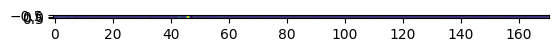

In [11]:
from matplotlib import pyplot as plt

plt.imshow(lrp_output[1][0].detach().float().cpu().numpy())

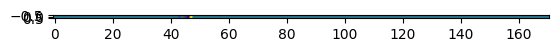

In [12]:
plt.imshow(lrp_output[1][1].detach().float().cpu().numpy())

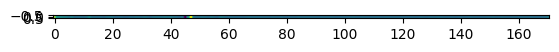

In [13]:
plt.imshow(lrp_output[1][2].detach().float().cpu().numpy())

In [21]:
torch.stack(lrp_output[1]).sum(dim=0).topk(5)

torch.return_types.topk(
values=tensor([[0.0281, 0.0151, 0.0050, 0.0044, 0.0038]], dtype=torch.bfloat16),
indices=tensor([[46, 47,  0,  2,  6]]))